In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pickle

with open('../data/processed/team_matches.pkl', 'rb') as f:
    team_matches = pickle.load(f)
                 
with open('../data/raw/european_leagues_data.pkl', 'rb') as f:
    all_matches = pickle.load(f)

In [3]:
print(team_matches['league'].unique())
print(team_matches['season'].unique())

<StringArray>
['Serie_A', 'Premier_League', 'La_Liga', 'Bundesliga', 'Ligue_1']
Length: 5, dtype: str
<StringArray>
['2526', '2425', '2324', '2223', '2122', '2021', '1920', '1819', '1718',
 '1617', '1516', '1415', '1314', '1213', '1112']
Length: 15, dtype: str


# Fouls, Cards and Randomness: a statistical analysis of fouls in Serie A


## Introduction

Football is a sport where players try to follow their manager's instruction while taking  split-second decisions, charged with adrenaline while watched from their fans (and opposite fan). But most of the time we forget one of the ingredients that makes this game loved by so many people: a fair amount of pure luck. A late tackle, a raised elbow, a foot that stayed on the ground half a second too long: fouls seem almost random, yet they tell us something systematic about how a team plays.

In this notebook we will analyse fouls committed and received in Serie A during the 2025/26 season (still ongoing). The aim is not just to answer questions about the league but also using football data to explain how statistical reasoning works: why we use certain tools, when they work, and when they lead us astray.

We will follow a deliberately iterative approach: we show every step, including the wrong ones, because that is how data analysis actually works — not how it appears in scientific papers.

> **Note:** The data covers the 2025/26 Italian Serie A season up to the matchday available at the time of analysis, i.e 22/03/2026. Results are therefore partial by definition.


In [4]:
ita_2526 = team_matches[
    (team_matches['league'] == 'Serie_A') &
    (team_matches['season'] == '2526')
].copy()

dates = pd.to_datetime(ita_2526['date'], dayfirst=True)

print(f"Rows loaded: {len(ita_2526)}")
print(f"Matches played: {len(ita_2526) // 2}")
print(f"Teams: {ita_2526['team'].nunique()}")
print(f"Date range: {dates.min().strftime('%d/%m/%Y')} → {dates.max().strftime('%d/%m/%Y')}")
ita_2526.head()


Rows loaded: 600
Matches played: 300
Teams: 20
Date range: 23/08/2025 → 22/03/2026


,season,date,team,opponent,yellow_cards,red_cards,fouls_committed,fouls_received,shots,shots_opponent,shots_on_target,shots_on_target_opponent,corners,corners_opponent,goals_scored,goals_conceded,match_result,venue,team_result,league
0,2526,23/08/2025,Genoa,Lecce,2.0,0.0,16.0,13.0,5.0,7.0,2.0,0.0,3.0,7.0,0.0,0.0,D,home,D,Serie_A
1,2526,23/08/2025,Sassuolo,Napoli,3.0,1.0,17.0,17.0,7.0,13.0,2.0,4.0,1.0,2.0,0.0,2.0,A,home,L,Serie_A
2,2526,23/08/2025,Milan,Cremonese,1.0,0.0,10.0,14.0,24.0,4.0,6.0,3.0,9.0,2.0,1.0,2.0,A,home,L,Serie_A
3,2526,23/08/2025,Roma,Bologna,1.0,0.0,15.0,13.0,14.0,10.0,4.0,2.0,2.0,4.0,1.0,0.0,H,home,W,Serie_A
4,2526,24/08/2025,Cagliari,Fiorentina,4.0,0.0,18.0,14.0,14.0,4.0,6.0,1.0,3.0,2.0,1.0,1.0,D,home,D,Serie_A


A quick note on the data structure: each match appears **twice** in the dataframe: once for each team's perspective. So Genoa vs Lecce generates one row where Genoa's fouls are `fouls_committed`, and one where Lecce's are. This is intentional: it lets us treat every team symmetrically without reshaping the data later.

## 1. How are fouls distributed?

Before asking whether teams differ from each other, we need to understand the overall shape of the data. How many fouls are typically committed in a Serie A match? Is the distribution symmetric? Are there outliers?

We start with the simplest possible question: if you picked a random Serie A match from this season, how many fouls would you expect to see from one team?

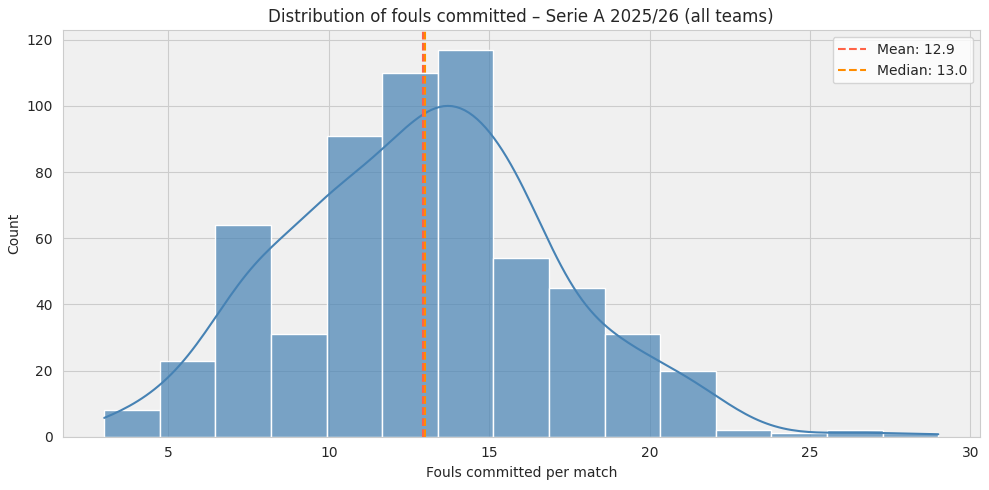

In [5]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f0f0f0')
    
    sns.histplot(ita_2526['fouls_committed'], 
                 bins=15, 
                 kde=True,
                 color='steelblue', 
                 alpha=0.7, 
                 ax=ax)
    
    ax.axvline(ita_2526['fouls_committed'].mean(), color='tomato', 
               linestyle='--', linewidth=1.5, label=f"Mean: {ita_2526['fouls_committed'].mean():.1f}")
    ax.axvline(ita_2526['fouls_committed'].median(), color='darkorange', 
               linestyle='--', linewidth=1.5, label=f"Median: {ita_2526['fouls_committed'].median():.1f}")
    
    ax.set_xlabel('Fouls committed per match')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of fouls committed – Serie A 2025/26 (all teams)')
    ax.legend()
    plt.tight_layout()


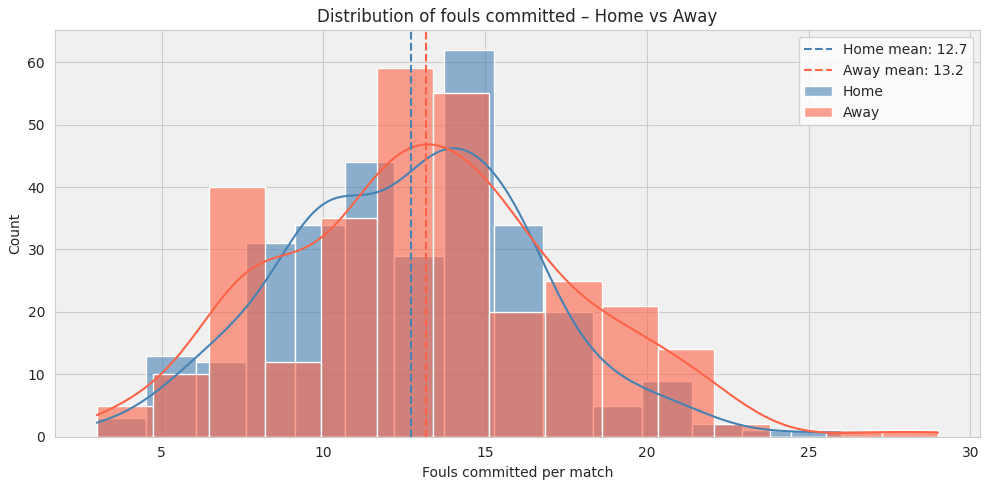

In [6]:
home = ita_2526[ita_2526['venue'] == 'home']['fouls_committed']
away = ita_2526[ita_2526['venue'] == 'away']['fouls_committed']

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f0f0f0')

    sns.histplot(home, bins=15, kde=True, color='steelblue', alpha=0.6, label='Home', ax=ax)
    sns.histplot(away, bins=15, kde=True, color='tomato', alpha=0.6, label='Away', ax=ax)

    ax.axvline(home.mean(), color='steelblue', linestyle='--', linewidth=1.5,
               label=f'Home mean: {home.mean():.1f}')
    ax.axvline(away.mean(), color='tomato', linestyle='--', linewidth=1.5,
               label=f'Away mean: {away.mean():.1f}')

    ax.set_xlabel('Fouls committed per match')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of fouls committed – Home vs Away')
    ax.legend()
    plt.tight_layout()



### What do we see?

The overall distribution is roughly bell-shaped, centred around **13 fouls per match**. Mean (12.9) and median (13.0) values are also very close and this is very telling. When mean and median are this close, it is in fact a first signal that the distribution is fairly symmetric, without extreme values pulling the average in one direction.

There is a mild right tail, some occasional matches where a team commits more than 25 fouls. But broadly, fouls in Serie A cluster predictably around that 13-foul mark.

Now look at the home vs. away split. Two things stand out immediately:

- **Away teams commit more fouls**: the red distribution is shifted to the right relative to the blue one.
- **The away distribution is wider and more skewed**: away teams are not just fouling more on average, they are also more variable, some away sides barely foul, others rack up big numbers.

At first glance, you might be tempted to compare the two peaks and call it a day. 
Don't do that.

Look more carefully at the blue (home) curve. There is a secondary bump around 10 fouls  
(a shoulder on the left side of the main peak) before the distribution rises to its maximum 
around 14. That leftward pull is what drags the home mean *down*, even though the two peaks 
are at similar heights. The home curve is also asymmetric in the other direction: it drops 
sharply after the peak, with few home teams racking up very high foul counts.

The away curve tells a different story: it rises more steeply, peaks slightly higher, and 
has a longer right tail, meaning away teams are not just fouling more on average, they also 
occasionally have very high-foul matches.

This is a good reminder that two distributions can look similar at a glance and still behave 
quite differently. Summary statistics like mean and median help, but they are no substitute for  looking at the full shape.

A small but important observation: the combined distribution (all teams, first plot) looks *more normal* than either the home or away distributions individually. Mixing two slightly different groups together smooths out the peaks and fills in the gaps. This is a preview of an important statistical idea we will come back to.

In conclusion we could say that playing away from home means more pressure, less comfort, more desperate defending and all of which translate into more fouls: 13.2 vs 12.7. 

> But is this difference *real*, or could it just be random variation? That is exactly what we will test in the next section.

In [7]:
ita_2526.groupby('venue')['fouls_committed'].describe()

,count,mean,std,min,25%,50%,75%,max
venue,,,,,,,,
away,300.0,13.166667,4.452524,3.0,10.0,13.0,16.0,29.0
home,300.0,12.720000,3.838060,3.0,10.0,13.0,15.0,26.0


The numbers confirm what the plot suggested, but with some nuance worth unpacking.

The **median is identical** (the 50%) for both groups: 13 fouls per match, home or away. If you only looked at the middle of the distribution, you would conclude there is no difference at all.

The mean tells a slightly different story: away teams average **13.2 fouls** vs **12.7 for  home teams**, a gap of roughly half a foul per match. Small, but consistent.

Where the real difference lives is in the **spread**: the away standard deviation (4.45) is 
noticeably larger than the home one (3.84). Away teams are not just fouling marginally more,  they are also *less predictable*. The away maximum (29 fouls) is also higher than the home 
maximum (26), and the 75th percentile is one foul higher (16 vs 15).

In plain terms: home teams foul a bit less and are more consistent. Away teams foul a bit 
more and occasionally have very high-foul matches that pull the mean and widen the spread.

This is a textbook example of why you should never summarise a distribution with a single 
number. Mean, median, and standard deviation together start to tell a coherent story, and 
even then, the plot adds things the numbers alone cannot show.

So: is this half-a-foul-per-match difference actually meaningful, or is it just noise? 
That is the question we will address next.

## 2. Is the difference real? Introducing hypothesis testing

As I discussed previously, hypothesis testing is one of the fundamental tools in statistics. But let's do a quick, grounded recap before we use it.

### The core idea

Suppose we want to study how many fouls a team commits when playing and we notice that they are committing more fouls when playing away. We can have two possible explanations:

1. **There is a real effect**: playing away genuinely causes your team to foul more, due to more pressure, less comfort, more desperate defending.
2. **It is just noise**: the difference you observed happened by chance, and if you played the same matches again, it might go the other way.

Hypothesis testing is a formal way of asking: *how surprised should I be by this data if explanation 2 were true?*

We start by assuming explanation 2 is true, called the **null hypothesis**: there is no difference between home and away fouls, and whatever we observe is just random variation. Then we ask: given that assumption, how likely is it that we would see a difference at least as large as the one we actually observed?

If the answer is "very unlikely", we have reason to doubt the null hypothesis and lean towards explanation 1. If the answer is "quite plausible", we cannot rule out that we just got unlucky with the data.


### A word on p-values

The number that comes out of this calculation is called the **p-value**. It is, loosely, the probability of observing data at least as extreme as yours *if the null hypothesis were true*.

The conventional threshold is **0.05**: if the p-value is below 0.05, we say the result is "statistically significant" and reject the null hypothesis.

Now, the p-value is one of the most misunderstood and misused numbers in all of science. There are entire academic debates, still ongoing, about how to interpret it, whether 0.05 is the right threshold, why that threshold should be set *before* looking at the data, and why a p-value alone tells you almost nothing about practical importance.

I am not going to open any kind of discussion here as I care about my life. I will not take side in any debate but what I think is safe to say and want you to take away is this:

- A small p-value does **not** mean the effect is large or important: it means the data is unlikely under the null hypothesis
- The threshold of 0.05 is a **convention**, not a law of nature
- Statistical significance and practical significance are **not the same thing**

With that caveat firmly in place, let's use it carefully, slowly and without taking any knives behind our backs. And I hope that using these concepts in the rest of our analysis, you will have a more firm grasp on them.

### Checking assumptions: is this data normal enough?

Before we run any test, we need to check whether our data is roughly normally distributed. This matters because the simplest and most well-known tests, like the t-test, assume *normality*. If the data is wildly non-normal, those tests can give misleading results.

We already looked at the histograms and they seemed reasonably bell-shaped. But "looks fine to me" is not a rigorous check. Let's use two approaches:

1. **Visual**: a Q-Q plot, which compares our data against what a perfect normal distribution would look like
2. **Formal**: the ***Shapiro-Wilk test***, which gives us a p-value for the null hypothesis "this data is drawn from a normal distribution"

A word of caution: with 300 observations per group, the Shapiro-Wilk test is quite sensitive and it will flag even minor departures from normality as "significant". So we should not treat it as a pass/fail gate. Instead, we use both the visual and the formal check together.

### But first: what does "normal" actually mean in practice?

Before we check normality, we should explain what we even mean by "normal".

When someone tells you "Serie A teams commit 13 fouls per match, give or take 4", your brain automatically pictures something symmetric: roughly half the time it's a bit more, roughly half the time it's a bit less, and extreme values are rare on both sides.

That "give or take" — the **plus or minus** — is doing more work than you think. It quietly assumes that the error is **balanced around the mean**: that being 4 fouls above average is just as likely as being 4 fouls below. That the spread is the same in both directions. That the mean sits in the middle of the distribution.

This is what a normal distribution looks like. And when data is truly normal, the mean and the standard deviation tell you almost everything: where the centre is, how wide the spread is, and how rare extreme values are. The famous 68-95-99.7 rule — 68% of values within one standard deviation, 95% within two, 99.7% within three — only works if the distribution is normal.

But what if the data is **not** symmetric? What if being 4 fouls above average is more common than being 4 fouls below — because some matches produce an unusually high number of fouls, but there is a natural floor (you cannot commit fewer than zero)?

In that case, "plus or minus 4" is **misleading**. The error is not balanced. The mean is not in the middle. And the 68-95-99.7 rule does not apply. The standard deviation is still a valid number — it still measures spread — but its intuitive meaning changes. You can no longer assume that values are evenly scattered around the mean.

This is why checking for normality matters. Not because it is a bureaucratic box to tick, but because it tells you **whether your intuitions about "plus or minus" are safe to use**.


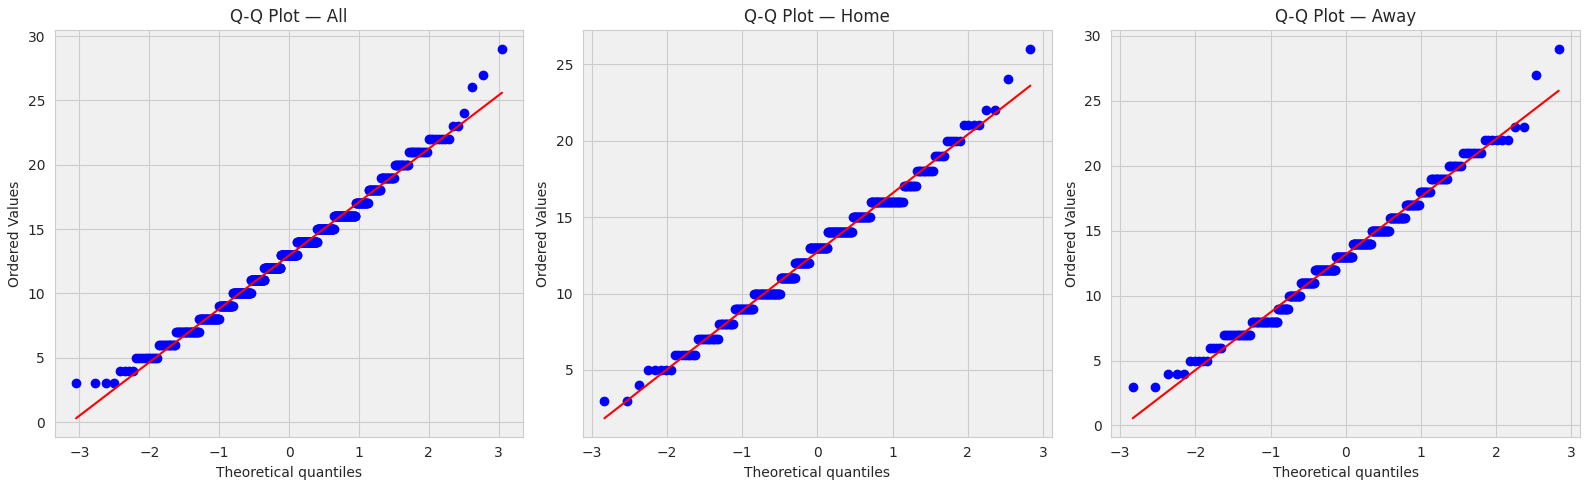

In [8]:
from scipy import stats

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, (label, data) in zip(axes, [
        ('All', ita_2526['fouls_committed']),
        ('Home', ita_2526[ita_2526['venue'] == 'home']['fouls_committed']),
        ('Away', ita_2526[ita_2526['venue'] == 'away']['fouls_committed'])
    ]):
        ax.set_facecolor('#f0f0f0')
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot — {label}')
    
    plt.tight_layout()


In [9]:
for label, data in [
    ('All', ita_2526['fouls_committed']),
    ('Home', ita_2526[ita_2526['venue'] == 'home']['fouls_committed']),
    ('Away', ita_2526[ita_2526['venue'] == 'away']['fouls_committed'])
]:
    stat, p = stats.shapiro(data)
    print(f"{label:6s} — W={stat:.4f}, p={p:.4f} {'✓ Normal (p>0.05)' if p > 0.05 else '✗ Not normal (p<0.05)'}")


All    — W=0.9894, p=0.0002 ✗ Not normal (p<0.05)
Home   — W=0.9887, p=0.0196 ✗ Not normal (p<0.05)
Away   — W=0.9873, p=0.0096 ✗ Not normal (p<0.05)


### Reading the results

Let's start with the Q-Q plots. If our data were perfectly normal, all the blue dots would sit exactly on the red line. What we see instead is:

- In the **middle** of the distribution (roughly 5 to 20 fouls), the points follow the line very closely. This is the bulk of our data, and it behaves normally.
- At the **lower end** (left side), the points flatten out — they cluster around 3 fouls instead of dropping as low as a normal distribution would predict. This makes sense: there is a natural floor. A team cannot commit negative fouls, and it is very rare to commit fewer than 3 in a professional match.
- At the **upper end** (right side), the points curve above the line — meaning we observe more very high-foul matches than a normal distribution would expect. These are the 25+ foul matches we spotted in the histogram.

In short: the data is **approximately normal in the middle, but has a compressed left tail and a stretched right tail**. Statisticians call this a mild right skew.


Now the Shapiro-Wilk test. All three groups — all, home, away — came back as "not normal" (p < 0.05).

Should we panic? No.

Remember what we said: with 300 observations, the Shapiro-Wilk test is very sensitive. It detects departures from normality that are **statistically real but practically small**. Look at the W statistics — all above 0.987 (the maximum is 1.0, which would mean perfect normality). These are very high values. The test is essentially saying: "this is not *perfectly* normal, and I have enough data to be sure about it".

The Q-Q plots tell the same story in more useful terms: the deviation from normality lives in the tails, not in the centre where most of our data sits.

So what do we do? We have two honest options:

1. **Proceed with tests that assume normality** (like the t-test), knowing the assumption is slightly violated but probably not enough to ruin the results
2. **Use tests that do not require normality at all** (like Mann-Whitney or bootstrapping), as a safer alternative

We will do both — and compare. This is good practice in general: if a parametric test and a non-parametric test agree, you can be more confident in the conclusion. If they disagree, the non-parametric result is usually the one to trust.


### The t-test: the simplest comparison

The t-test asks a straightforward question: are the means of two groups different enough that the difference is unlikely to be due to chance alone?

In our case: is the average number of fouls committed at home (12.7) different enough from the average committed away (13.2) that we can rule out random variation?

The **Student's t-test** assumes two things:
1. Both groups are normally distributed (we just saw this is *approximately* true)
2. Both groups have **equal variance** (the spread is the same)

Let's check assumption 2 first with Levene's test, then run the t-test regardless — we want to see what happens.


In [10]:
home_fouls = ita_2526[ita_2526['venue'] == 'home']['fouls_committed']
away_fouls = ita_2526[ita_2526['venue'] == 'away']['fouls_committed']

# Check equal variance
lev_stat, lev_p = stats.levene(home_fouls, away_fouls)
print(f"Levene's test: F={lev_stat:.4f}, p={lev_p:.4f}")
print(f"Equal variance? {'Yes (p>0.05)' if lev_p > 0.05 else 'No (p<0.05)'}")
print()

# Student's t-test (assumes equal variance)
t_stat, t_p = stats.ttest_ind(home_fouls, away_fouls, equal_var=True)
print(f"Student's t-test: t={t_stat:.4f}, p={t_p:.4f}")
print(f"Significant at 0.05? {'Yes' if t_p < 0.05 else 'No'}")

Levene's test: F=4.9457, p=0.0265
Equal variance? No (p<0.05)

Student's t-test: t=-1.3161, p=0.1886
Significant at 0.05? No


### What just happened?

Two results to unpack:

- **Levene's test** tells us the variances are **not equal** (p=0.027). This confirms what we saw in the descriptive statistics: away fouls have a standard deviation of 4.45 vs. 3.84 for home. The spread is genuinely different, not just by chance.
- This is a problem, because we just ran a Student's t-test that **assumes** equal variance. The result (p=0.189, not significant) might not be reliable. We used a tool that requires an assumption we already know is violated.

In practice, this is a common situation. You run a test, it gives you a number, and then you realise one of its assumptions does not hold. What do you do?

You use a test that does not need that assumption. Enter Welch's t-test.

### Welch's t-test: dropping the equal variance assumption

Welch's t-test is almost identical to Student's, but it does **not** assume equal variance. It adjusts the degrees of freedom to account for different spreads in the two groups. In practice, many statisticians argue you should just always use Welch's by default (there is rarely a good reason to assume equal variance when you can simply not assume it).


In [11]:
# Welch's t-test (does not assume equal variance)
t_stat_w, t_p_w = stats.ttest_ind(home_fouls, away_fouls, equal_var=False)

print(f"Welch's t-test: t={t_stat_w:.4f}, p={t_p_w:.4f}")
print(f"Significant at 0.05? {'Yes' if t_p_w < 0.05 else 'No'}")

Welch's t-test: t=-1.3161, p=0.1887
Significant at 0.05? No


### Same answer, but it's a clue that we trust it more

The Welch's t-test gives us essentially the same result: t=-1.32, p=0.189. Not significant.

The p-value barely changed (from 0.1886 to 0.1887). This tells us something useful: in this case, the unequal variance was not distorting the Student's t-test by much. The two tests agree, which is reassuring.

Summing up what we just did:

1. We ran a test (Student's)
2. We checked its assumptions and found one was violated (equal variance)
3. We ran a more appropriate test (Welch's)
4. The results agreed and so now we are more confident the conclusion is solid

This is an appropriate workflow. If the two tests had **disagreed**, we would trust Welch's. Since they agree, we can report either. In the meantime, we learned something about our data in the process.

Now, both tests still assume normality, and we also know that is not perfectly satisfied. So let's take one more step and use a test that makes **no distributional assumptions at all**.

### Mann-Whitney U test: no assumptions about the shape

The Mann-Whitney U test takes a completely different approach. Instead of comparing means and assuming a bell curve, it asks: **if I pick a random home match and a random away match, is one group consistently higher than the other?**

It works by ranking all the values together (home and away mixed) and then checking whether one group's ranks are systematically higher. It does not care about the shape of the distribution, only about the ordering.

This makes it more robust, but it answers a slightly different question. The t-test asks "are the means different?". Mann-Whitney asks "does one group tend to produce larger values than the other?". When the distributions have similar shapes, these questions are practically equivalent. When the shapes differ, like in our case, Mann-Whitney is the safer bet.

In [12]:
# Mann-Whitney U test
u_stat, u_p = stats.mannwhitneyu(home_fouls, away_fouls, alternative='two-sided')

# Effect size: rank-biserial correlation
n1, n2 = len(home_fouls), len(away_fouls)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print(f"Mann-Whitney U test: U={u_stat:.1f}, p={u_p:.4f}")
print(f"Significant at 0.05? {'Yes' if u_p < 0.05 else 'No'}")
print(f"Effect size (rank-biserial): {rank_biserial:.4f}")

Mann-Whitney U test: U=42798.0, p=0.2984
Significant at 0.05? No
Effect size (rank-biserial): 0.0489


## 3. Under the hood: how Mann-Whitney actually works

We said that Mann-Whitney ranks all values together and checks whether one group's ranks are systematically higher. But what does that actually look like? Let's see it with our data.

The next python cell does this:
1. You have, for each game, the number of home and away fouls 
2. From all games, you pick 8 random samples from both lists of home and away number of fouls
3. You rank these 16 random samples, meaning that you order them and assign their rank. So, the game with fewer fouls you rank it 1; the next 2 and so on. 
4. You then consider the sum of the ranks for home and away list. For example (I am considering just four samples), if the home games have ranked 1,3,5,8 and 2,4,6,7 for away game, than the sum for home will be 17 and the sum for away will be 19  

In [13]:
# Take a small sample to make it readable
np.random.seed(42)
home_sample = home_fouls.sample(8).reset_index(drop=True)
away_sample = away_fouls.sample(8).reset_index(drop=True)

# Build a combined dataframe and rank
combined = pd.DataFrame({
    'fouls': pd.concat([home_sample, away_sample], ignore_index=True),
    'venue': ['Home']*8 + ['Away']*8
})
combined['rank'] = combined['fouls'].rank()
combined = combined.sort_values('rank').reset_index(drop=True)

print(combined.to_string(index=False))
print(f"\nSum of Home ranks: {combined[combined['venue']=='Home']['rank'].sum():.1f}")
print(f"Sum of Away ranks: {combined[combined['venue']=='Away']['rank'].sum():.1f}")

 fouls venue  rank
   7.0  Away   1.0
  10.0  Home   2.0
  11.0  Home   3.0
  12.0  Away   4.0
  13.0  Home   5.0
  14.0  Away   8.0
  14.0  Away   8.0
  14.0  Home   8.0
  14.0  Away   8.0
  14.0  Away   8.0
  15.0  Home  11.0
  16.0  Home  12.5
  16.0  Away  12.5
  19.0  Home  14.5
  19.0  Away  14.5
  26.0  Home  16.0

Sum of Home ranks: 72.0
Sum of Away ranks: 64.0


A few things to notice:

- Several matches have the **same number of fouls** (five matches with 14 fouls, for instance). When this happens, the ranking assigns them the **average of the ranks they would have occupied**. The five matches with 14 fouls would have taken ranks 6, 7, 8, 9, 10 — so they all get rank 8.0. This avoids arbitrarily favouring one group over the other.
- The sum of Home ranks (72) and Away ranks (64) are close. If away teams systematically fouled more, we would expect their ranks to be concentrated towards the top, producing a much higher rank sum.
- This is just 16 data points. The full Mann-Whitney test does this with all 600 rows — same logic, bigger scale, more reliable conclusion.

### From rank sums to the U statistic

We computed rank sums, but the test reports a **U statistic**. How are they connected?

The U statistic counts something very concrete: **how many times a value from one group beats a value from the other group**. In our small example with 8 home and 8 away values, we compare every possible home-away pair (8 × 8 = 64 pairs) and count how many times the away foul count is higher than the home foul count.

Mathematically, U is derived directly from the rank sums. For the away group:

$$U_{away} = R_{away} - \frac{n_{away}(n_{away}+1)}{2}$$

where $R_{away}$ is the sum of away ranks and $n_{away}$ is the number of away observations. The second term is a correction — it subtracts the minimum possible rank sum (what the group would score if it held all the lowest ranks).

Let's see this with our small sample:

In [14]:
n = 8  # per group

R_home = 72.0
R_away = 64.0

U_home = R_home - n * (n + 1) / 2
U_away = R_away - n * (n + 1) / 2

print(f"R_home = {R_home}, R_away = {R_away}")
print(f"U_home = {R_home} - {n*(n+1)/2} = {U_home}")
print(f"U_away = {R_away} - {n*(n+1)/2} = {U_away}")
print(f"\nTotal pairs: {n}×{n} = {n*n}")
print(f"U_home + U_away = {U_home + U_away} (always equals n×n = {n*n})")

R_home = 72.0, R_away = 64.0
U_home = 72.0 - 36.0 = 36.0
U_away = 64.0 - 36.0 = 28.0

Total pairs: 8×8 = 64
U_home + U_away = 64.0 (always equals n×n = 64)


Notice that $U_{home} + U_{away}$ always equals the total number of pairs ($n \times n$). This makes sense: every pair is either a "home wins", an "away wins", or a tie — and they must add up.

The test reports the **smaller** of the two U values (or, depending on the implementation, one of them). A U value close to $\frac{n \times n}{2}$ — halfway — means the two groups are evenly matched. A U value close to 0 or close to $n \times n$ means one group is systematically beating the other.

In our full dataset (300 vs. 300), the total number of pairs is 90,000. We got U = 42,798, very close to 45,000 (the midpoint). This confirms what we already know: home and away fouls are almost indistinguishable by rank.

This is the entire logic of the Mann-Whitney test. Forget the means, forget the bell curve. Just look at the ranks.

If home and away fouls were truly identical, i.e. if playing at home made no difference at all, we would expect the Home and Away ranks to be **roughly interleaved**: some high, some low, evenly mixed. The sum of ranks for each group would be similar.

If instead one group consistently ranked higher, the rank sums would be very different — and that is what the test detects.

With our full dataset (300 vs. 300), the same logic applies, just at a larger scale. The U statistic we got earlier (42,798) is derived from these rank sums. The p-value (0.298) tells us: the rank sums are well within what you would expect from random shuffling. No systematic difference.

The beauty of this approach is that it does not care whether the values are 3 or 300 — only their **order** matters. This is why it is robust to outliers and non-normal distributions: a single match with 29 fouls gets rank 600 instead of rank 590, but it does not drag a mean upwards like it would in a t-test.

## 4. Bootstrapping: letting the data speak for itself

### The idea

Bootstrapping takes a radically different approach to the question "is this difference real?". Instead of relying on mathematical formulas and distributional assumptions, it uses **brute force simulation**.

The logic goes like this:

1. We observed a difference in means: away teams commit 0.45 more fouls per match than home teams
2. **If there were no real difference** between home and away, then the labels "home" and "away" would be meaningless, we could shuffle them randomly and the difference would look similar
3. So let's do exactly that: **thousands of times**, we randomly reassign the "home" and "away" labels, compute the difference in means each time, and build up a distribution of differences that arise purely from chance
4. Then we check: where does our observed difference (0.45) sit within that distribution? If it is deep inside — surrounded by similar values, then chance alone can easily produce it. If it is way out in the tail, something real is going on.

This is called a **permutation test** (a close cousin of bootstrapping). No normality required. No equal variance required. No formulas beyond "compute the mean". Just shuffling and counting.

### How it works, step by step

Let's make this very concrete with a tiny example before running it at scale.

We have 600 rows of fouls — 300 labelled "home" and 300 labelled "away". The observed difference in means is 0.45 (away teams foul more).

Now imagine the null hypothesis is true: home and away make no difference. If that is the case, the label attached to each foul count is **arbitrary**, a match with 14 fouls is equally likely to have been a home match or an away match.

So here is what we do:

1. **Pool** all 600 values together, ignoring the labels
2. **Shuffle** — randomly assign 300 of them to "home" and 300 to "away"
3. **Compute** the difference in means between the two shuffled groups
4. **Repeat** steps 2-3 thousands of times
5. **Compare**: where does our real difference (0.45) fall in the distribution of shuffled differences?

Let's see one single shuffle to make it tangible:

In [15]:
np.random.seed(99)

pooled = np.concatenate([home_fouls.values, away_fouls.values])
n_home = len(home_fouls)

# One single shuffle
shuffled = pooled.copy()
np.random.shuffle(shuffled)

fake_home = shuffled[:n_home]
fake_away = shuffled[n_home:]
fake_diff = fake_away.mean() - fake_home.mean()

print(f"Real home mean:     {home_fouls.mean():.2f}")
print(f"Real away mean:     {away_fouls.mean():.2f}")
print(f"Real difference:    {away_fouls.mean() - home_fouls.mean():.2f}")
print()
print(f"Shuffled 'home' mean: {fake_home.mean():.2f}")
print(f"Shuffled 'away' mean: {fake_away.mean():.2f}")
print(f"Shuffled difference:  {fake_diff:.2f}")

Real home mean:     12.72
Real away mean:     13.17
Real difference:    0.45

Shuffled 'home' mean: 12.57
Shuffled 'away' mean: 13.32
Shuffled difference:  0.75


With one shuffle, the random relabelling produced a difference of 0.75, actually **larger** than our real difference of 0.45. And this happened purely by chance, because we destroyed the real labels. If a single random shuffle can beat the real effect, how special can that effect really be?

Now we do this 10,000 times and collect all the fake differences. If our real difference (0.45) is typical among them — if chance alone regularly produces differences of 0.45 or larger — then we have no reason to believe the real labels matter.

That is exactly what the next cell does:


In [16]:
np.random.seed(42)

observed_diff = away_fouls.mean() - home_fouls.mean()

# Pool all fouls together
pooled = np.concatenate([home_fouls.values, away_fouls.values])
n_home = len(home_fouls)

# Permutation test: shuffle labels 10,000 times
n_permutations = 10_000
perm_diffs = np.zeros(n_permutations)

for i in range(n_permutations):
    np.random.shuffle(pooled)
    perm_diffs[i] = pooled[n_home:].mean() - pooled[:n_home].mean()

# p-value: how often does the shuffled difference exceed our observed one?
p_bootstrap = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print(f"Observed difference (away - home): {observed_diff:.4f}")
print(f"Bootstrap p-value (two-sided): {p_bootstrap:.4f}")


Observed difference (away - home): 0.4467
Bootstrap p-value (two-sided): 0.1935


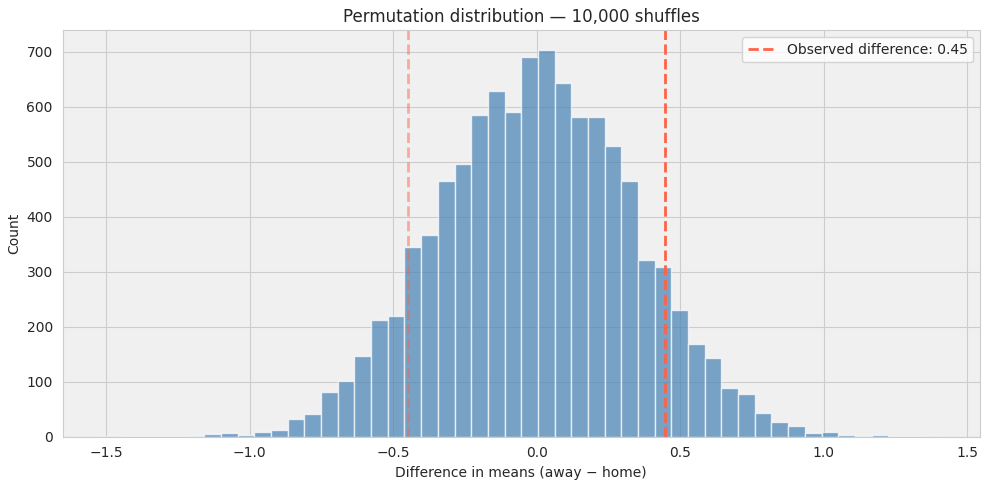

In [17]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f0f0f0')
    
    ax.hist(perm_diffs, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(observed_diff, color='tomato', linestyle='--', linewidth=2,
               label=f'Observed difference: {observed_diff:.2f}')
    ax.axvline(-observed_diff, color='tomato', linestyle='--', linewidth=2, alpha=0.5)
    
    ax.set_xlabel('Difference in means (away − home)')
    ax.set_ylabel('Count')
    ax.set_title('Permutation distribution — 10,000 shuffles')
    ax.legend()
    plt.tight_layout()


So the bootstrapping approach agrees with all the other tests. Let's put them side by side: The histogram shows what happens when we randomly shuffle the home/away labels 10,000 times: the differences in means form a nice bell curve centred at zero — exactly what we would expect if the labels did not matter.

The red dashed line is our **observed** difference (0.45 fouls). It sits comfortably inside the distribution — not in the tail, not even close to being unusual. The bootstrap p-value confirms this numerically.

This is perhaps the most intuitive way to understand what "not statistically significant" means: **our observed difference is the kind of difference that arises easily by chance alone**. There is nothing special about it.

The power of bootstrapping is that you can *see* this directly, without trusting a formula or checking assumptions. The data speaks for itself — you just have to let it shuffle enough times.

### Putting it all together

Four different approaches, zero assumptions left unchecked, one consistent answer:

| Test | Assumes normality | Assumes equal variance | p-value | Significant? |
|------|:-:|:-:|---------|:--:|
| Student's t-test | Yes | Yes | 0.189 | No |
| Welch's t-test | Yes | No | 0.189 | No |
| Mann-Whitney U | No | No | 0.298 | No |
| Permutation test | No | No | 0.194 | No |

Every test agrees: the difference between home and away fouls is **not statistically significant**. And we arrived at this conclusion through increasingly relaxed assumptions — from "data is normal with equal variance" all the way to "just shuffle and count". The answer did not change.

This is exactly the kind of robustness you want. When a conclusion survives multiple methods with different assumptions, you can trust it. When it flips depending on the method, you should worry.

The 0.45 extra fouls per match committed by away teams is a real pattern in this data — but it is small enough that random variation alone can easily produce it. We cannot, with statistical honesty, call it a meaningful difference. Not yet, at least — more data from the rest of the season might change this.


## 5. Does any team stand out? One team vs. the rest

So far we have looked at home vs. away, i.e. a property of the match. Now we ask a different question: **are some teams systematically more aggressive than others?**

Specifically, for each team we ask: is this team's average fouls per match different enough from the rest of the league that we can rule out chance?

This is the same logic as before, but with an important structural difference. In the home vs. away comparison, we had two balanced groups (300 vs. 300). Here, we are comparing **one team (~30 matches) against the rest of the league (~570 matches)**. The groups are very unbalanced — which is exactly why we learned about Welch's t-test and Mann-Whitney earlier.

### First look: who fouls the most?

Before running any tests, let's just look at the numbers. A simple table of mean fouls per match, sorted from most to least aggressive:

In [18]:
team_stats = (
    ita_2526
    .groupby('team')['fouls_committed']
    .agg(['sum', 'mean', 'std', 'count'])
    .round(2)
    .sort_values('mean', ascending=False)
)

team_stats = team_stats.rename(columns={'sum': 'total'})

league_mean = ita_2526['fouls_committed'].mean()
team_stats['diff_from_league'] = (team_stats['mean'] - league_mean).round(2)

print(f"League average: {league_mean:.2f} fouls per match\n")
team_stats


League average: 12.94 fouls per match



,total,mean,std,count,diff_from_league
team,,,,,
Verona,478.0,15.93,3.66,30,2.99
Cagliari,451.0,15.03,3.32,30,2.09
Roma,437.0,14.57,3.61,30,1.63
Torino,429.0,14.30,4.96,30,1.36
Udinese,424.0,14.13,3.90,30,1.19
Como,412.0,13.73,4.31,30,0.79
Cremonese,411.0,13.70,4.65,30,0.76
Bologna,409.0,13.63,4.17,30,0.69
Inter,406.0,13.53,5.36,30,0.59


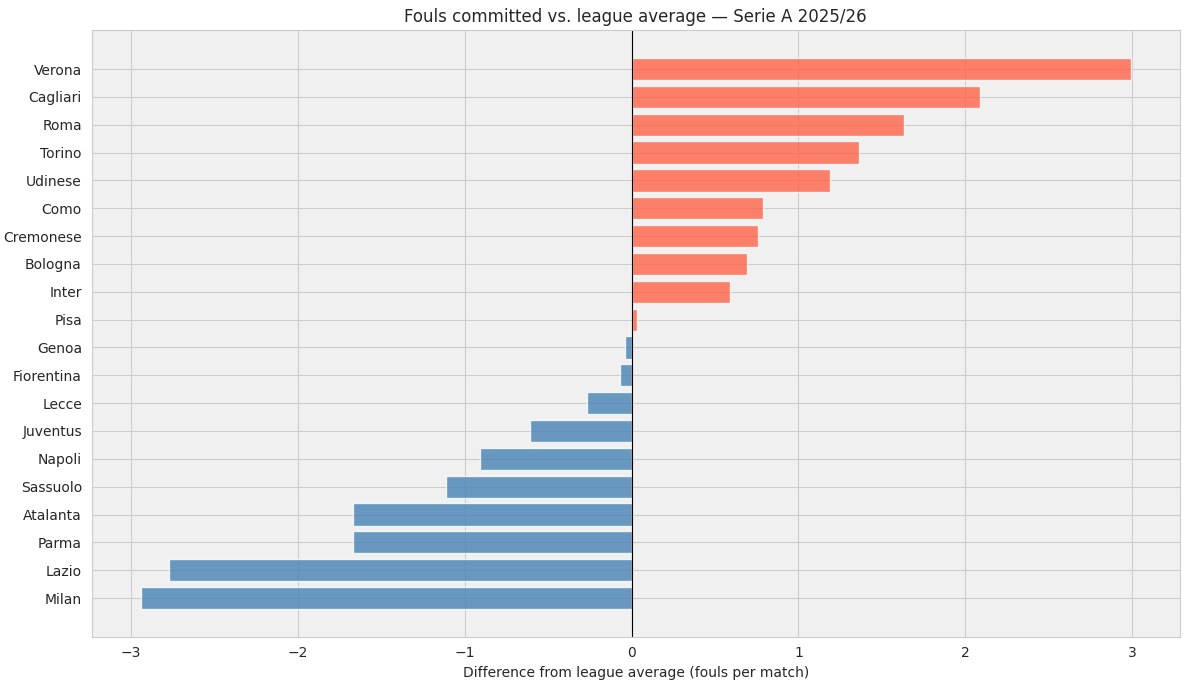

In [19]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_facecolor('#f0f0f0')

    colors = ['tomato' if x > 0 else 'steelblue' for x in team_stats['diff_from_league']]
    
    ax.barh(team_stats.index, team_stats['diff_from_league'], color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Difference from league average (fouls per match)')
    ax.set_title('Fouls committed vs. league average — Serie A 2025/26')
    ax.invert_yaxis()
    plt.tight_layout()


### What stands out?

The spread is significant: Verona averages almost 16 fouls per match, Milan barely 10. That is a gap of 6 fouls per match — nearly half the league average. Over 30 matches, Verona has committed 478 fouls vs. Milan's 300: 178 more fouls, or roughly 6 extra fouls every single game.

A few observations:

- **The extremes are symmetric**: the top 2 teams (Verona, Cagliari) are about 2-3 fouls above average, the bottom 2 (Lazio, Milan) are about 2-3 fouls below. The league is not skewed towards aggressive or clean teams — it fans out evenly.
- **The middle is crowded**: from Como to Lecce, eight teams sit within ±0.8 fouls of the league average. These teams are essentially indistinguishable by this metric alone.
- **Variability matters too**: look at the standard deviations. Torino (std=4.96) and Inter (std=5.36) are the most unpredictable — they swing between very clean and very dirty matches. Fiorentina (std=2.79) is the most consistent: you know roughly what you are going to get.

But the question remains: are Verona and Milan genuinely different from the pack, or is this just what 30 matches of random variation looks like? Let's test the extremes first, then all 20 teams.


In [20]:
def test_team_vs_rest(df, team_name, n_permutations=10_000):
    team = df[df['team'] == team_name]['fouls_committed']
    rest = df[df['team'] != team_name]['fouls_committed']
    
    # Student's t-test
    t_stat_s, t_p_s = stats.ttest_ind(team, rest, equal_var=True)
    
    # Welch's t-test
    t_stat_w, t_p_w = stats.ttest_ind(team, rest, equal_var=False)
    
    # Mann-Whitney U
    u_stat, u_p = stats.mannwhitneyu(team, rest, alternative='two-sided')
    
    # Permutation test
    observed_diff = team.mean() - rest.mean()
    pooled = np.concatenate([team.values, rest.values])
    n_team = len(team)
    perm_diffs = np.zeros(n_permutations)
    for i in range(n_permutations):
        np.random.shuffle(pooled)
        perm_diffs[i] = pooled[:n_team].mean() - pooled[n_team:].mean()
    p_perm = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    
    # Effect size: Cohen's d
    pooled_std = np.sqrt((team.std()**2 + rest.std()**2) / 2)
    cohens_d = observed_diff / pooled_std
    
    print(f"--- {team_name} ---")
    print(f"Team mean: {team.mean():.2f}  |  Rest mean: {rest.mean():.2f}  |  Diff: {observed_diff:.2f}")
    print(f"Student's t-test:  t={t_stat_s:.3f}, p={t_p_s:.4f}")
    print(f"Welch's t-test:    t={t_stat_w:.3f}, p={t_p_w:.4f}")
    print(f"Mann-Whitney U:    U={u_stat:.1f}, p={u_p:.4f}")
    print(f"Permutation test:  p={p_perm:.4f}")
    print(f"Cohen's d:         {cohens_d:.3f}")
    print()

np.random.seed(42)
test_team_vs_rest(ita_2526, 'Verona')
test_team_vs_rest(ita_2526, 'Milan')

--- Verona ---
Team mean: 15.93  |  Rest mean: 12.79  |  Diff: 3.15
Student's t-test:  t=4.093, p=0.0000
Welch's t-test:    t=4.563, p=0.0001
Mann-Whitney U:    U=12164.5, p=0.0001
Permutation test:  p=0.0000
Cohen's d:         0.807

--- Milan ---
Team mean: 10.00  |  Rest mean: 13.10  |  Diff: -3.10
Student's t-test:  t=-4.027, p=0.0001
Welch's t-test:    t=-5.139, p=0.0000
Mann-Whitney U:    U=4574.0, p=0.0000
Permutation test:  p=0.0001
Cohen's d:         -0.840



### Now that's a different story

Compare this with the home vs. away results. There, every p-value was above 0.05 and we could not reject the null hypothesis. Here, every single test — all four of them — returns a p-value below 0.001 for both Verona and Milan. The agreement is unanimous and emphatic.

| | Student's t | Welch's t | Mann-Whitney | Permutation | Cohen's d |
|--|:-:|:-:|:-:|:-:|:-:|
| **Verona** | p<0.001 | p<0.001 | p<0.001 | p<0.001 | 0.81 |
| **Milan** | p<0.001 | p<0.001 | p<0.001 | p<0.001 | -0.84 |

The Cohen's d values are around 0.8 in magnitude — which is conventionally considered a **large** effect. For context: the home vs. away difference had a rank-biserial of 0.05, which is tiny. Here we are in a completely different territory.

In plain terms: Verona commits roughly 3 extra fouls per match compared to the rest of the league, and Milan commits 3 fewer. These are not random fluctuations — they are consistent patterns across 30 matches, robust to every statistical method we have thrown at them.

A small but important note: the Student's t-test and Welch's t-test give **different** t-statistics here (4.09 vs. 4.56 for Verona, -4.03 vs. -5.14 for Milan). This is because the sample sizes are very unequal (30 vs. 570), so the equal variance assumption matters more than it did in the balanced home vs. away comparison. Welch's is the one to trust here.


### What about everyone else?

Verona and Milan are the extremes. But what about the other 18 teams? Let's run the same tests across the full league and see which teams are genuinely different from the pack — and which are just noise.

In [21]:
np.random.seed(42)

results = []
for team_name in team_stats.index:
    team = ita_2526[ita_2526['team'] == team_name]['fouls_committed']
    rest = ita_2526[ita_2526['team'] != team_name]['fouls_committed']
    
    _, t_p = stats.ttest_ind(team, rest, equal_var=False)
    _, u_p = stats.mannwhitneyu(team, rest, alternative='two-sided')
    
    observed_diff = team.mean() - rest.mean()
    pooled = np.concatenate([team.values, rest.values])
    n_team = len(team)
    perm_diffs = np.zeros(10_000)
    for i in range(10_000):
        np.random.shuffle(pooled)
        perm_diffs[i] = pooled[:n_team].mean() - pooled[n_team:].mean()
    p_perm = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    
    pooled_std = np.sqrt((team.std()**2 + rest.std()**2) / 2)
    cohens_d = observed_diff / pooled_std
    
    results.append({
        'team': team_name,
        'mean': team.mean(),
        'diff': observed_diff,
        'welch_p': t_p,
        'mannwhitney_p': u_p,
        'perm_p': p_perm,
        'cohens_d': cohens_d
    })

results_df = pd.DataFrame(results).sort_values('mean', ascending=False).round(4)
results_df

,team,mean,diff,welch_p,mannwhitney_p,perm_p,cohens_d
0,Verona,15.9333,3.1474,0.0001,0.0001,0.0000,0.8072
1,Cagliari,15.0333,2.2000,0.0014,0.0019,0.0052,0.5837
2,Roma,14.5667,1.7088,0.0172,0.0165,0.0287,0.4382
3,Torino,14.3000,1.4281,0.1316,0.0737,0.0653,0.3136
4,Udinese,14.1333,1.2526,0.0972,0.0847,0.1139,0.3104
5,Como,13.7333,0.8316,0.3095,0.2885,0.2969,0.1966
6,Cremonese,13.7000,0.7965,0.3647,0.3318,0.3072,0.1811
7,Bologna,13.6333,0.7263,0.3596,0.2773,0.3602,0.1743
8,Inter,13.5333,0.6211,0.5366,0.9611,0.4388,0.1303
9,Pisa,12.9667,0.0246,0.9742,0.9301,0.9811,0.0060


In [22]:
results_df[(results_df['mannwhitney_p'] < 0.05) & (results_df['diff'] > 0)]

,team,mean,diff,welch_p,mannwhitney_p,perm_p,cohens_d
0,Verona,15.9333,3.1474,0.0001,0.0001,0.0000,0.8072
1,Cagliari,15.0333,2.2000,0.0014,0.0019,0.0052,0.5837
2,Roma,14.5667,1.7088,0.0172,0.0165,0.0287,0.4382


### Reading the full league table

Now we can see the full picture. Let's group the teams by what the tests tell us:

**Significantly more aggressive than the league** (all tests p < 0.05):
- **Verona** (d=0.81) — the clear outlier. Nearly 16 fouls per match, 3 more than the rest. Large effect.
- **Cagliari** (d=0.58) — 15 fouls per match. Medium-to-large effect.
- **Roma** (d=0.44) — just over the threshold. A smaller but real effect.

**Significantly less aggressive than the league** (all tests p < 0.05):
- **Milan** (d=-0.84) — the cleanest team. 10 fouls per match, 3 fewer than the rest. Large effect.
- **Lazio** (d=-0.78) — very close to Milan. Also a large effect.
- **Atalanta** (d=-0.47) — medium effect.
- **Parma** (d=-0.43) — medium effect, though the Welch's p-value (0.026) is closer to the threshold.

**The grey zone** (some tests near 0.05, others not):
- **Torino** — interesting case. Mann-Whitney (p=0.074) and the permutation test (p=0.065) hint at something, but Welch's (p=0.132) does not. With a high standard deviation of 4.96, Torino is wildly inconsistent — which makes it harder for any test to reach significance.

**Indistinguishable from average** (all tests p > 0.1):
- Everyone from Udinese down to Sassuolo. Pisa and Genoa are almost surgically average — their p-values are above 0.9.

A few things worth reflecting on:

**Effect sizes matter more than p-values here.** Verona (d=0.81) and Milan (d=-0.84) have large effects — these are teams with genuinely different playing styles. Roma (d=0.44) and Atalanta (d=-0.47) have medium effects — real but less dramatic. Everything in between is small or negligible.

**The tests mostly agree — but not always.** Look at Torino: depending on which test you trust, you could argue they are marginally significant or not significant at all. This is exactly the kind of borderline case where a single p-value threshold (0.05) creates an artificial boundary. Torino is not cleanly "different" or "average" — it is somewhere in between, and that is an honest answer.

**Inter is a curious case.** Their mean (13.5) is above average, but their Mann-Whitney p-value (0.96) says they are completely average in terms of rank. The explanation is in their standard deviation (5.36 — the highest in the league). Inter's mean is pulled up by a few very high-foul matches, but most of their games are unremarkable. The mean and the distribution tell different stories.


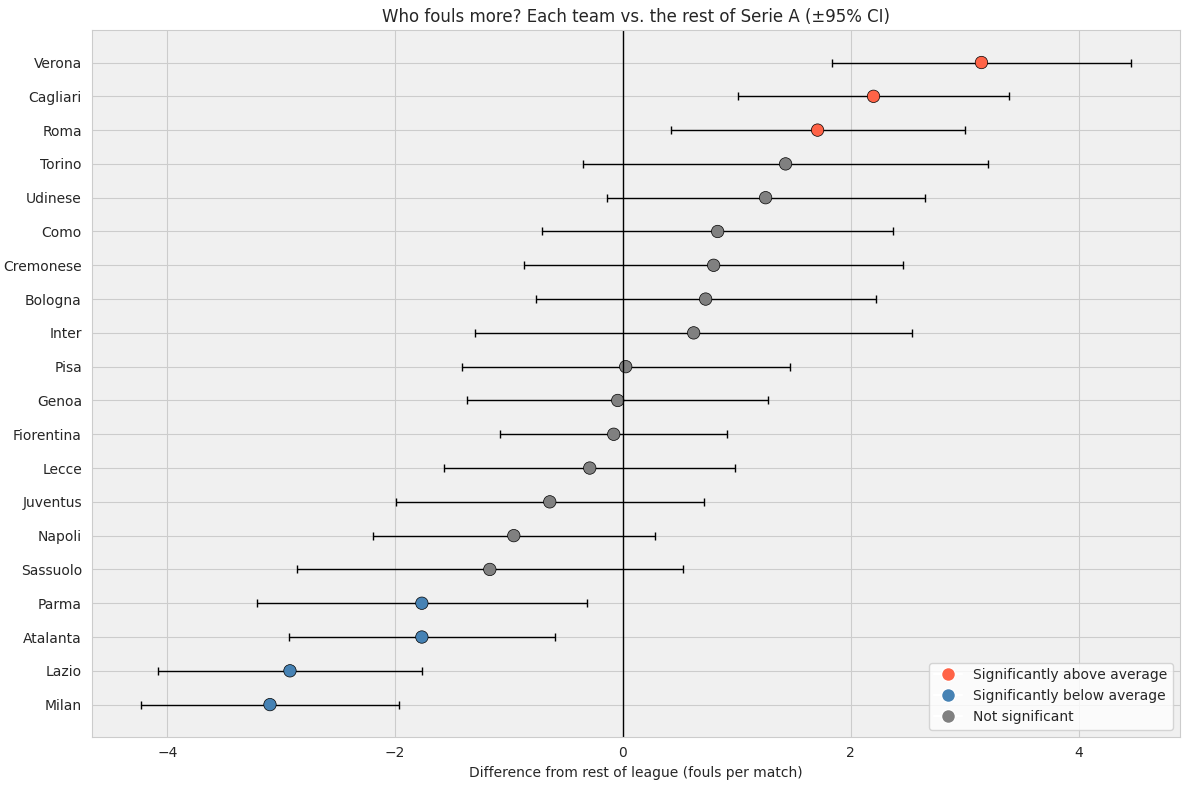

In [25]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_facecolor('#f0f0f0')

    # Sort by mean difference
    plot_df = results_df.sort_values('diff', ascending=True)
    
    # Compute 95% CI for each team using their std and count
    ci_data = []
    for _, row in plot_df.iterrows():
        team_data = ita_2526[ita_2526['team'] == row['team']]['fouls_committed']
        se = team_data.std() / np.sqrt(len(team_data))
        ci_data.append(se * 1.96)
    
    plot_df = plot_df.copy()
    plot_df['ci'] = ci_data
    
    # Color by significance (Welch p < 0.05)
    colors = ['tomato' if p < 0.05 and d > 0 
              else 'steelblue' if p < 0.05 and d < 0 
              else 'grey' 
              for p, d in zip(plot_df['welch_p'], plot_df['diff'])]
    
    y_pos = range(len(plot_df))
    
    ax.errorbar(plot_df['diff'], y_pos, xerr=plot_df['ci'], 
                fmt='none', ecolor='black', elinewidth=1, capsize=3, zorder=1)
    ax.scatter(plot_df['diff'], y_pos, c=colors, s=80, zorder=2, edgecolors='black', linewidth=0.5)
    
    ax.axvline(0, color='black', linewidth=1, linestyle='-')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(plot_df['team'])
    ax.set_xlabel('Difference from rest of league (fouls per match)')
    ax.set_title('Who fouls more? Each team vs. the rest of Serie A (±95% CI)')

    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', markersize=10, label='Significantly above average'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='Significantly below average'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=10, label='Not significant')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()


## 6. Wrapping up: what did we learn?


### About Serie A 2025/26

- **Home vs. away makes little difference in fouling** — about half a foul per match, not statistically significant. Whatever advantage playing at home gives you, it does not meaningfully reduce how much you foul.
- **Teams, on the other hand, are very different.** Verona and Cagliari are genuinely aggressive — their foul rates are significantly above the league average with large effect sizes. Milan and Lazio are genuinely clean. The gap between the most and least aggressive team is 6 fouls per match — nearly half the league average.
- **Most teams are average.** Ten out of twenty teams are statistically indistinguishable from the league mean. This is not surprising — it is what you would expect if fouling has a large random component with a smaller team-specific signal on top.
- **Consistency varies as much as aggression.** Torino and Inter have the highest standard deviations — they swing between very clean and very dirty matches. Fiorentina is the most predictable. This matters: a team that averages 14 fouls with a std of 5 is a very different beast from one that averages 14 with a std of 3.


### About statistics

- **"Plus or minus" is not as simple as it sounds.** It assumes symmetry, and real data is rarely perfectly symmetric. Always look at the shape before trusting a summary number.
- **A single test is never enough.** We ran four different tests with different assumptions and checked whether they agreed. When they did, we trusted the conclusion. When they disagreed (Torino), we reported the ambiguity honestly.
- **Statistical significance is not the same as practical significance.** The home vs. away difference was real in the data (0.45 fouls) but too small relative to the noise to be called significant. Verona's difference was both statistically and practically significant. Cohen's d helped us tell the two apart.
- **The most powerful tool is the simplest one.** The permutation test — just shuffle and count — requires no formulas, no distributional assumptions, and produces a result you can visualise and understand intuitively. If you take one method away from this notebook, make it that one.


## Bonus: comparing two teams head to head


### Which test for two teams?

So far we compared one team against the rest of the league (30 vs. 570 observations). What if we want to compare two specific teams — say, Verona vs. Milan?

The setup is different: now we have two small, equally-sized groups (30 vs. 30). With small samples:

- **Student's t-test** is risky — normality matters more with small samples, and we already know our data is not perfectly normal
- **Welch's t-test** is safer — it handles unequal variances, which is likely when comparing teams with different playing styles
- **Mann-Whitney** is the most robust — it does not care about normality or variance, only about ranks
- **Permutation test** is the safest of all — no assumptions whatsoever

For a general-purpose function that works across any pair of teams, **Mann-Whitney is the best default**: it is robust, well-understood, and appropriate for the sample sizes we have. We include Welch's and the permutation test for completeness.


In [26]:
def compare_two_teams(df, team_a, team_b, n_permutations=10_000):
    """Compare fouls committed between two teams."""
    a = df[df['team'] == team_a]['fouls_committed']
    b = df[df['team'] == team_b]['fouls_committed']
    
    diff = a.mean() - b.mean()
    
    # Welch's t-test
    _, welch_p = stats.ttest_ind(a, b, equal_var=False)
    
    # Mann-Whitney U
    u_stat, mw_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    n1, n2 = len(a), len(b)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
    
    # Permutation test
    pooled = np.concatenate([a.values, b.values])
    n_a = len(a)
    perm_diffs = np.zeros(n_permutations)
    for i in range(n_permutations):
        np.random.shuffle(pooled)
        perm_diffs[i] = pooled[:n_a].mean() - pooled[n_a:].mean()
    perm_p = np.mean(np.abs(perm_diffs) >= np.abs(diff))
    
    # Cohen's d
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    cohens_d = diff / pooled_std
    
    # Results
    print(f"{'='*50}")
    print(f"  {team_a} vs {team_b}")
    print(f"{'='*50}")
    print(f"  {team_a:15s}  mean={a.mean():.2f}  std={a.std():.2f}  n={len(a)}")
    print(f"  {team_b:15s}  mean={b.mean():.2f}  std={b.std():.2f}  n={len(b)}")
    print(f"  Difference:    {diff:+.2f} fouls/match")
    print(f"{'─'*50}")
    print(f"  Welch's t-test:    p={welch_p:.4f}")
    print(f"  Mann-Whitney U:    p={mw_p:.4f}")
    print(f"  Permutation test:  p={perm_p:.4f}")
    print(f"  Cohen's d:         {cohens_d:.3f}")
    print(f"  Rank-biserial:     {rank_biserial:.3f}")
    print(f"{'='*50}")
    
    return {
        'team_a': team_a, 'team_b': team_b,
        'mean_a': a.mean(), 'mean_b': b.mean(), 'diff': diff,
        'welch_p': welch_p, 'mannwhitney_p': mw_p, 'perm_p': perm_p,
        'cohens_d': cohens_d, 'rank_biserial': rank_biserial
    }

np.random.seed(42)
_ = compare_two_teams(ita_2526, 'Verona', 'Milan')


  Verona vs Milan
  Verona           mean=15.93  std=3.66  n=30
  Milan            mean=10.00  std=3.16  n=30
  Difference:    +5.93 fouls/match
──────────────────────────────────────────────────
  Welch's t-test:    p=0.0000
  Mann-Whitney U:    p=0.0000
  Permutation test:  p=0.0000
  Cohen's d:         1.736
  Rank-biserial:     -0.798


In [27]:
np.random.seed(42)
_ = compare_two_teams(ita_2526, 'Roma', 'Torino')
print()
_ = compare_two_teams(ita_2526, 'Napoli', 'Juventus')


  Roma vs Torino
  Roma             mean=14.57  std=3.61  n=30
  Torino           mean=14.30  std=4.96  n=30
  Difference:    +0.27 fouls/match
──────────────────────────────────────────────────
  Welch's t-test:    p=0.8128
  Mann-Whitney U:    p=0.8470
  Permutation test:  p=0.8366
  Cohen's d:         0.061
  Rank-biserial:     -0.030

  Napoli vs Juventus
  Napoli           mean=12.03  std=3.46  n=30
  Juventus         mean=12.33  std=3.77  n=30
  Difference:    -0.30 fouls/match
──────────────────────────────────────────────────
  Welch's t-test:    p=0.7493
  Mann-Whitney U:    p=0.7050
  Permutation test:  p=0.7679
  Cohen's d:         -0.083
  Rank-biserial:     0.058


Three very different stories:

- **Verona vs. Milan** (d=1.74, p<0.001): almost 6 fouls per match apart. The difference is enormous and beyond any doubt. These two teams play fundamentally different football in terms of physicality.
- **Roma vs. Torino** (d=0.06, p=0.81): 0.27 fouls apart. Pure noise. You could swap their labels and nobody would notice.
- **Napoli vs. Juventus** (d=-0.08, p=0.75): same story. Two teams that foul at almost exactly the same rate.

This function is a building block. It takes two teams, runs three tests, reports effect sizes, and lets the numbers speak. No assumptions hidden, no conclusions forced. It could live in a Streamlit app, a dashboard, or the next notebook in this series — wherever the question "who fouls more?" needs an honest answer.


---

# Appendix

## Data Dictionary

### `all_matches`



| Column | Description |
|--------|-------------|
| `Date` | Match date (dd/mm/yy) |
| `HomeTeam` | Name of the home team |
| `AwayTeam` | Name of the away team |
| `FTHG` | Full-time goals scored by the home team |
| `FTAG` | Full-time goals scored by the away team |
| `FTR` | Full-time result: `H` = Home win, `D` = Draw, `A` = Away win |
| `HTHG` | Half-time goals scored by the home team |
| `HTAG` | Half-time goals scored by the away team |
| `HTR` | Half-time result: `H` = Home win, `D` = Draw, `A` = Away win |
| `HF` | Fouls committed by the home team |
| `AF` | Fouls committed by the away team |
| `HY` | Yellow cards received by the home team |
| `AY` | Yellow cards received by the away team |
| `HR` | Red cards received by the home team |
| `AR` | Red cards received by the away team |
| `HS` | Shots taken by the home team |
| `AS` | Shots taken by the away team |
| `HST` | Shots on target by the home team |
| `AST` | Shots on target by the away team |
| `HC` | Corners won by the home team |
| `AC` | Corners won by the away team |
| `season` | Season identifier (e.g. `2526` for the 2025/26 season) |



## Data Dictionary

### `team_matches`

| Column | Description |
|--------|-------------|
| `season` | Season identifier (e.g. `2526` for the 2025/26 season) |
| `date` | Match date (dd/mm/yyyy, stored as string) |
| `team` | The team this row describes |
| `opponent` | The opposing team |
| `yellow_cards` | Yellow cards received by `team` |
| `red_cards` | Red cards received by `team` |
| `fouls_committed` | Fouls committed by `team` |
| `fouls_received` | Fouls committed by `opponent` against `team` |
| `shots` | Shots taken by `team` |
| `shots_opponent` | Shots taken by `opponent` |
| `shots_on_target` | Shots on target by `team` |
| `shots_on_target_opponent` | Shots on target by `opponent` |
| `corners` | Corners won by `team` |
| `corners_opponent` | Corners won by `opponent` |
| `goals_scored` | Goals scored by `team` |
| `goals_conceded` | Goals conceded by `team` |
| `match_result` | Full-time result from `team`'s perspective (`W` = win, `D` = draw, `L` = loss) |
| `venue` | Whether `team` played `home` or `away` |
| `team_result` | Match score or result string |
| `league` | League name (`Serie_A`, `Premier_League`, `La_Liga`, `Bundesliga`, `Ligue_1`) |


> **Note:** Each match generates two rows — one per team — with perspective-dependent columns (`fouls_committed`/`fouls_received`, `shots`/`shots_opponent`, etc.) swapped accordingly.


In [29]:
# import json

# with open('02b_fuols_analysis.ipynb') as f:
#     nb = json.load(f)

# for i, c in enumerate(nb['cells']):
#     src = ''.join(c['source'])[:100].replace('\n', ' ')
#     print(f"[{i:3d}] {c['cell_type']:8s} | {src}")
